# 1.Introduction to PyTorch

In [1]:
import torch
zeros = torch.zeros(5, 3)
print("Tensor filled with zeros : ",zeros)
print("DataType : ",zeros.dtype)

Tensor filled with zeros :  tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
DataType :  torch.float32


In [2]:
torch.manual_seed(1729)
random = torch.rand(2, 2)
print("A random tensor: ", random)

random2= torch.rand(2, 2)
print("Another random tensor: ", random2)

torch.manual_seed(1729)
random3 = torch.rand(2, 2)
print("A random tensor: ", random3)

A random tensor:  tensor([[0.3126, 0.3791],
        [0.3087, 0.0736]])
Another random tensor:  tensor([[0.4216, 0.0691],
        [0.2332, 0.4047]])
A random tensor:  tensor([[0.3126, 0.3791],
        [0.3087, 0.0736]])


### Arithmetic operations on tensors

In [3]:
Tensor1 = torch.ones(2, 3)
print(Tensor1)
Tensor2 = torch.ones(2, 3) * 5
print(Tensor2)

Tensor3 = Tensor1 + Tensor2      
print(Tensor3)              
print(Tensor3.shape)     

r1 = torch.rand(3, 3)
r2 = torch.rand(3, 3)
r3 = r1 + r2
print(r3)

r1 = torch.rand(2, 3)
r2 = torch.rand(3, 3)
r3 = r1 + r2
print(r3)

tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([[5., 5., 5.],
        [5., 5., 5.]])
tensor([[6., 6., 6.],
        [6., 6., 6.]])
torch.Size([2, 3])
tensor([[0.5735, 0.1144, 0.7367],
        [1.4025, 0.6046, 1.6856],
        [0.5831, 0.7323, 1.0887]])


RuntimeError: The size of tensor a (2) must match the size of tensor b (3) at non-singleton dimension 0

In [4]:
random = torch.rand(2, 2) - 0.5
print(random)

print("Maximum value of r: ", torch.max(random))
print("Average and standard deviation of r: ",torch.std_mean(random))
print("Determinant of r: ", torch.det(random))


tensor([[0.0999, 0.0013],
        [0.4397, 0.3656]])
Maximum value of r:  tensor(0.4397)
Average and standard deviation of r:  (tensor(0.2094), tensor(0.2266))
Determinant of r:  tensor(0.0359)


## Models In Pytorch

In [5]:
import torch      
import torch.nn as nn        
import torch.nn.functional as F

class LeNet(nn.Module):

    def __init__(self):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 3)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        num_features = 1
        size = x.size()[1:]
        for s in size:
            num_features *= s
        return num_features

net = LeNet()
print(net)  
    
input = torch.rand(1, 1, 32, 32)
print('Image batch shape:')
print(input.shape)
    
output = net(input)     
print('Raw output:')
print(output)
print(output.shape)

LeNet(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)
Image batch shape:
torch.Size([1, 1, 32, 32])
Raw output:
tensor([[ 0.0437,  0.0459, -0.1334, -0.0813,  0.0266, -0.1104, -0.0743, -0.0827,
         -0.0537,  0.0363]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])


## DataSet And DataLoaders

In [6]:
%matplotlib inline

import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])


In [7]:
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

Files already downloaded and verified


In [8]:
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

 deer   car  bird plane


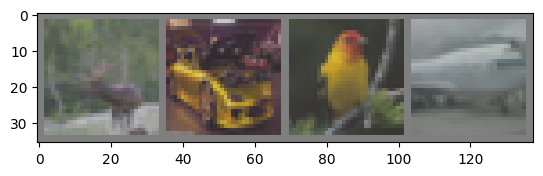

In [12]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img):
    img = img / 3 + 0.5  
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

## Training Pytorch Model

In [13]:
%matplotlib inline

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [14]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


truck truck   car   cat


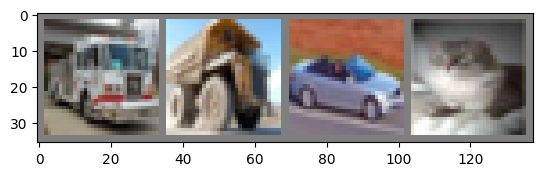

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5    
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))


dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join('%5s' % classes[labels[j]] for j in range(4)))

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)  
        self.conv2 = nn.Conv2d(6, 16, 5)  
        self.conv3 = nn.Conv2d(16, 32, 3)  
        self.pool = nn.MaxPool2d(2, 2)  

        self.flattened_size = None  

        self.fc1 = nn.Linear(1, 120)  # Temporary, will be updated dynamically
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 50)  
        self.fc4 = nn.Linear(50, 10)  

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))  

        if self.flattened_size is None:
            self.flattened_size = x.numel() // x.shape[0]  
            self.fc1 = nn.Linear(self.flattened_size, 120).to(x.device)  # Update dynamically

        x = x.view(-1, self.flattened_size)  
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))  
        x = self.fc4(x)  
        return x

net = Net()


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net.to(device)

num_epochs = 10
for epoch in range(num_epochs):
    running_loss = 0.0
    
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 2000 == 1999:
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')


[Epoch 1, Batch 2000] Loss: 2.303
[Epoch 1, Batch 4000] Loss: 2.287
[Epoch 1, Batch 6000] Loss: 2.076
[Epoch 1, Batch 8000] Loss: 1.936
[Epoch 1, Batch 10000] Loss: 1.842
[Epoch 1, Batch 12000] Loss: 1.767
[Epoch 2, Batch 2000] Loss: 1.693
[Epoch 2, Batch 4000] Loss: 1.654
[Epoch 2, Batch 6000] Loss: 1.622
[Epoch 2, Batch 8000] Loss: 1.591
[Epoch 2, Batch 10000] Loss: 1.570
[Epoch 2, Batch 12000] Loss: 1.537
[Epoch 3, Batch 2000] Loss: 1.505
[Epoch 3, Batch 4000] Loss: 1.485
[Epoch 3, Batch 6000] Loss: 1.468
[Epoch 3, Batch 8000] Loss: 1.473
[Epoch 3, Batch 10000] Loss: 1.433
[Epoch 3, Batch 12000] Loss: 1.456
[Epoch 4, Batch 2000] Loss: 1.412
[Epoch 4, Batch 4000] Loss: 1.394
[Epoch 4, Batch 6000] Loss: 1.392
[Epoch 4, Batch 8000] Loss: 1.383
[Epoch 4, Batch 10000] Loss: 1.401
[Epoch 4, Batch 12000] Loss: 1.344
[Epoch 5, Batch 2000] Loss: 1.338
[Epoch 5, Batch 4000] Loss: 1.326
[Epoch 5, Batch 6000] Loss: 1.328
[Epoch 5, Batch 8000] Loss: 1.345
[Epoch 5, Batch 10000] Loss: 1.331
[Epoc

In [25]:
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print('Accuracy of the network on the 10000 test images: %d %%' % (
    100 * correct / total))

Accuracy of the network on the 10000 test images: 56 %


# PyTorch Tensors


In [26]:
import torch
import math

x = torch.empty(3, 4)
print(type(x))
print(x)

<class 'torch.Tensor'>
tensor([[-2.9627e+25,  2.0039e-42,  1.3433e-01,  1.0736e-01],
        [ 1.3993e-01, -3.4579e-01,  1.7078e-02, -7.9392e-02],
        [ 2.2772e-02, -3.2581e-02,  0.0000e+00,  0.0000e+00]])


In [27]:
x = torch.empty(2, 2, 3)
print(x.shape)
print(x)

empty_like_x = torch.empty_like(x)
print(empty_like_x.shape)
print(empty_like_x)

zeros_like_x = torch.zeros_like(x)
print(zeros_like_x.shape)
print(zeros_like_x)

ones_like_x = torch.ones_like(x)
print(ones_like_x.shape)
print(ones_like_x)

rand_like_x = torch.rand_like(x)
print(rand_like_x.shape)
print(rand_like_x)

torch.Size([2, 2, 3])
tensor([[[-2.9627e+25,  2.0039e-42,  1.3433e-01],
         [ 1.0736e-01,  1.3993e-01, -3.4579e-01]],

        [[ 1.7078e-02, -7.9392e-02,  2.2772e-02],
         [-3.2581e-02,  0.0000e+00,  0.0000e+00]]])
torch.Size([2, 2, 3])
tensor([[[-0.2368,  0.0384,  0.1372],
         [-0.1676,  0.1470,  0.0659]],

        [[ 0.2096,  0.0387,  0.0020],
         [-0.2344,  0.0000,  0.0000]]])
torch.Size([2, 2, 3])
tensor([[[0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.]]])
torch.Size([2, 2, 3])
tensor([[[1., 1., 1.],
         [1., 1., 1.]],

        [[1., 1., 1.],
         [1., 1., 1.]]])
torch.Size([2, 2, 3])
tensor([[[0.9497, 0.5785, 0.9339],
         [0.3451, 0.0423, 0.3809]],

        [[0.9314, 0.9576, 0.6045],
         [0.0364, 0.6805, 0.1832]]])


In [28]:
some_constants = torch.tensor([[3.1415926, 2.71828], [1.61803, 0.0072897]])
print(some_constants)

some_integers = torch.tensor((2, 3, 5, 7, 11, 13, 17, 19))
print(some_integers)

more_integers = torch.tensor(((2, 4, 6), [3, 6, 9]))
print(more_integers)

tensor([[3.1416, 2.7183],
        [1.6180, 0.0073]])
tensor([ 2,  3,  5,  7, 11, 13, 17, 19])
tensor([[2, 4, 6],
        [3, 6, 9]])


## Math with Tensors

In [30]:
ones = torch.zeros(2, 2) + 1
twos = torch.ones(2, 2) * 2
threes = (torch.ones(2, 2) * 7 - 1) / 2
fours = twos ** 2 +1

print(ones)
print(twos)
print(threes)
print(fours)

tensor([[1., 1.],
        [1., 1.]])
tensor([[2., 2.],
        [2., 2.]])
tensor([[3., 3.],
        [3., 3.]])
tensor([[5., 5.],
        [5., 5.]])


In [31]:
a = torch.ones((2, 3), dtype=torch.int16)
print(a)

b = torch.rand((2, 3), dtype=torch.float64) * 20.
print(b)

c = b.to(torch.int32)
print(c)

tensor([[1, 1, 1],
        [1, 1, 1]], dtype=torch.int16)
tensor([[10.2924,  5.6861,  9.7183],
        [ 6.6064, 17.5590, 12.7090]], dtype=torch.float64)
tensor([[10,  5,  9],
        [ 6, 17, 12]], dtype=torch.int32)


In [32]:
a =     torch.ones(4, 3, 2)
b = a * torch.rand(4, 3, 2)    
c = a * torch.rand(4, 3, 2) 


In [34]:
# common functions
a = torch.rand(2, 4) * 2 - 1
print('Common functions:')
print(torch.abs(a))
print(torch.ceil(a))
print(torch.floor(a))
print(torch.clamp(a, -0.5, 0.5))

# trigonometric functions and their inverses
angles = torch.tensor([0, math.pi / 4, math.pi / 2, 3 * math.pi / 4])
print(angles)

# bitwise operations
print('\nBitwise XOR:')
b = torch.tensor([3, 5, 7])
c = torch.tensor([1, 5, 10])
print(torch.bitwise_xor(b, c))

# comparisons:
print('\nBroadcasted, element-wise equality comparison:')
d = torch.tensor([[1., 2.], [3., 4.]])
e = torch.ones(1, 2)  # many comparison ops support broadcasting!
print(torch.eq(d, e)) # returns a tensor of type bool

# reductions:
print('\nReduction ops:')
print(torch.max(d))        # returns a single-element tensor
print(torch.max(d).item()) # extracts the value from the returned tensor
print(torch.mean(d))       # average
print(torch.std(d))        # standard deviation
print(torch.prod(d))       # product of all numbers
print(torch.unique(torch.tensor([1, 2, 1, 2, 1, 2]))) # filter unique elements


Common functions:
tensor([[0.8433, 0.4333, 0.7618, 0.8764],
        [0.6655, 0.0521, 0.7868, 0.9831]])
tensor([[-0., -0., 1., -0.],
        [1., 1., 1., -0.]])
tensor([[-1., -1.,  0., -1.],
        [ 0.,  0.,  0., -1.]])
tensor([[-0.5000, -0.4333,  0.5000, -0.5000],
        [ 0.5000,  0.0521,  0.5000, -0.5000]])
tensor([0.0000, 0.7854, 1.5708, 2.3562])

Bitwise XOR:
tensor([ 2,  0, 13])

Broadcasted, element-wise equality comparison:
tensor([[ True, False],
        [False, False]])

Reduction ops:
tensor(4.)
4.0
tensor(2.5000)
tensor(1.2910)
tensor(24.)
tensor([1, 2])


In [35]:
a = torch.tensor([0, math.pi / 4, math.pi / 2, 3 * math.pi / 4])
print('a:')
print(a)
print(torch.sin(a))   # this operation creates a new tensor in memory
print(a)              # a has not changed

b = torch.tensor([0, math.pi / 4, math.pi / 2, 3 * math.pi / 4])
print('\nb:')
print(b)
print(torch.sin_(b))  # note the underscore
print(b)              # b has changed

a:
tensor([0.0000, 0.7854, 1.5708, 2.3562])
tensor([0.0000, 0.7071, 1.0000, 0.7071])
tensor([0.0000, 0.7854, 1.5708, 2.3562])

b:
tensor([0.0000, 0.7854, 1.5708, 2.3562])
tensor([0.0000, 0.7071, 1.0000, 0.7071])
tensor([0.0000, 0.7071, 1.0000, 0.7071])


## Copying Tensors


In [38]:
a = torch.ones(2, 2)
b = a

a[0][1] = 561  
print(b)       

a = torch.ones(2, 2)
b = a.clone()

assert b is not a      
print(torch.eq(a, b))  

a[0][1] = 561          
print(b)         

tensor([[  1., 561.],
        [  1.,   1.]])
tensor([[True, True],
        [True, True]])
tensor([[1., 1.],
        [1., 1.]])


In [39]:
if torch.cuda.is_available():
    print('dont have GPU!')
else:
    print('only Cpu.')


if torch.cuda.is_available():
    my_device = torch.device('cuda')
else:
    my_device = torch.device('cpu')
print('Device: {}'.format(my_device))

x = torch.rand(2, 2, device=my_device)
print(x)

only Cpu.
Device: cpu
tensor([[0.5869, 0.1865],
        [0.1928, 0.7278]])


In [40]:
a = torch.rand(3, 226, 226)
b = a.unsqueeze(0)

print(a.shape)
print(b.shape)

a = torch.rand(1, 20)
print(a.shape)
print(a)

b = a.squeeze(0)
print(b.shape)
print(b)

c = torch.rand(2, 2)
print(c.shape)

d = c.squeeze(0)
print(d.shape)

torch.Size([3, 226, 226])
torch.Size([1, 3, 226, 226])
torch.Size([1, 20])
tensor([[0.8030, 0.0103, 0.4095, 0.4365, 0.2433, 0.6462, 0.6691, 0.1689, 0.8444,
         0.2810, 0.2326, 0.7813, 0.8739, 0.0420, 0.6147, 0.3132, 0.5275, 0.7970,
         0.6608, 0.7166]])
torch.Size([20])
tensor([0.8030, 0.0103, 0.4095, 0.4365, 0.2433, 0.6462, 0.6691, 0.1689, 0.8444,
        0.2810, 0.2326, 0.7813, 0.8739, 0.0420, 0.6147, 0.3132, 0.5275, 0.7970,
        0.6608, 0.7166])
torch.Size([2, 2])
torch.Size([2, 2])


# Autograd


In [41]:
import torch

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math

tensor([0.0000, 0.1282, 0.2565, 0.3847, 0.5129, 0.6411, 0.7694, 0.8976, 1.0258,
        1.1541, 1.2823, 1.4105, 1.5387, 1.6670, 1.7952, 1.9234, 2.0517, 2.1799,
        2.3081, 2.4363, 2.5646, 2.6928, 2.8210, 2.9493, 3.0775, 3.2057, 3.3339,
        3.4622, 3.5904, 3.7186, 3.8468, 3.9751, 4.1033, 4.2315, 4.3598, 4.4880,
        4.6162, 4.7444, 4.8727, 5.0009, 5.1291, 5.2574, 5.3856, 5.5138, 5.6420,
        5.7703, 5.8985, 6.0267, 6.1550, 6.2832], requires_grad=True)


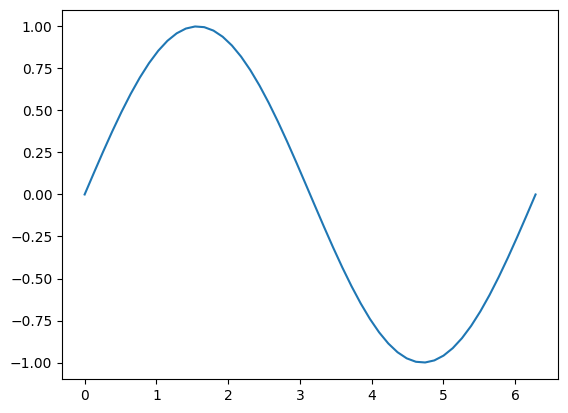

In [43]:
a = torch.linspace(0., 2. * math.pi, steps=50, requires_grad=True)
print(a)
b = torch.sin(a)
plt.plot(a.detach(), b.detach())

In [44]:
print(b)

tensor([ 0.0000e+00,  1.2788e-01,  2.5365e-01,  3.7527e-01,  4.9072e-01,
         5.9811e-01,  6.9568e-01,  7.8183e-01,  8.5514e-01,  9.1441e-01,
         9.5867e-01,  9.8718e-01,  9.9949e-01,  9.9538e-01,  9.7493e-01,
         9.3847e-01,  8.8660e-01,  8.2017e-01,  7.4028e-01,  6.4823e-01,
         5.4553e-01,  4.3388e-01,  3.1511e-01,  1.9116e-01,  6.4070e-02,
        -6.4070e-02, -1.9116e-01, -3.1511e-01, -4.3388e-01, -5.4553e-01,
        -6.4823e-01, -7.4028e-01, -8.2017e-01, -8.8660e-01, -9.3847e-01,
        -9.7493e-01, -9.9538e-01, -9.9949e-01, -9.8718e-01, -9.5867e-01,
        -9.1441e-01, -8.5514e-01, -7.8183e-01, -6.9568e-01, -5.9811e-01,
        -4.9072e-01, -3.7527e-01, -2.5365e-01, -1.2788e-01,  1.7485e-07],
       grad_fn=<SinBackward0>)


In [45]:
c = 2 * b
print(c)

d = c + 1
print(d)

tensor([ 0.0000e+00,  2.5575e-01,  5.0731e-01,  7.5053e-01,  9.8144e-01,
         1.1962e+00,  1.3914e+00,  1.5637e+00,  1.7103e+00,  1.8288e+00,
         1.9173e+00,  1.9744e+00,  1.9990e+00,  1.9908e+00,  1.9499e+00,
         1.8769e+00,  1.7732e+00,  1.6403e+00,  1.4806e+00,  1.2965e+00,
         1.0911e+00,  8.6777e-01,  6.3022e-01,  3.8232e-01,  1.2814e-01,
        -1.2814e-01, -3.8232e-01, -6.3022e-01, -8.6777e-01, -1.0911e+00,
        -1.2965e+00, -1.4806e+00, -1.6403e+00, -1.7732e+00, -1.8769e+00,
        -1.9499e+00, -1.9908e+00, -1.9990e+00, -1.9744e+00, -1.9173e+00,
        -1.8288e+00, -1.7103e+00, -1.5637e+00, -1.3914e+00, -1.1962e+00,
        -9.8144e-01, -7.5053e-01, -5.0731e-01, -2.5575e-01,  3.4969e-07],
       grad_fn=<MulBackward0>)
tensor([ 1.0000,  1.2558,  1.5073,  1.7505,  1.9814,  2.1962,  2.3914,  2.5637,
         2.7103,  2.8288,  2.9173,  2.9744,  2.9990,  2.9908,  2.9499,  2.8769,
         2.7732,  2.6403,  2.4806,  2.2965,  2.0911,  1.8678,  1.6302,  1.3823

In [46]:
out = d.sum()
print(out)
print('d:')
print(d.grad_fn)
print(d.grad_fn.next_functions)
print(d.grad_fn.next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions)
print(d.grad_fn.next_functions[0][0].next_functions[0][0].next_functions[0][0].next_functions)
print('\nc:')
print(c.grad_fn)
print('\nb:')
print(b.grad_fn)
print('\na:')
print(a.grad_fn)

tensor(50.0000, grad_fn=<SumBackward0>)
d:
((<MulBackward0 object at 0x00000107E2921E10>, 0), (None, 0))
((<SinBackward0 object at 0x00000107E293A1D0>, 0), (None, 0))
((<AccumulateGrad object at 0x00000107E2921E10>, 0),)
()

c:

b:

a:
None


tensor([ 2.0000,  1.9836,  1.9346,  1.8538,  1.7426,  1.6028,  1.4367,  1.2470,
         1.0368,  0.8096,  0.5691,  0.3192,  0.0641, -0.1920, -0.4450, -0.6907,
        -0.9251, -1.1442, -1.3446, -1.5229, -1.6762, -1.8019, -1.8981, -1.9631,
        -1.9959, -1.9959, -1.9631, -1.8981, -1.8019, -1.6762, -1.5229, -1.3446,
        -1.1442, -0.9251, -0.6907, -0.4450, -0.1920,  0.0641,  0.3192,  0.5691,
         0.8096,  1.0368,  1.2470,  1.4367,  1.6028,  1.7426,  1.8538,  1.9346,
         1.9836,  2.0000])


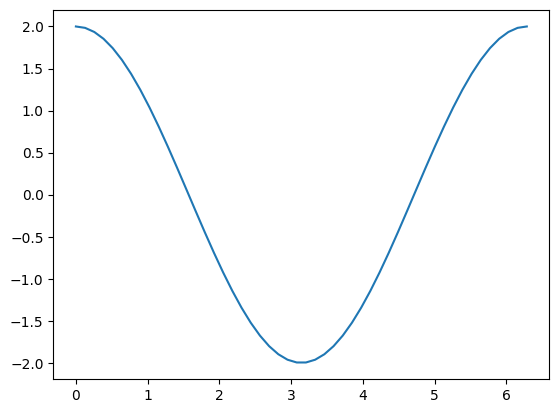

In [47]:
out.backward()
print(a.grad)
plt.plot(a.detach(), a.grad.detach())

## Training with Autograd


In [53]:
BATCH_SIZE = 32
DIM_IN = 1000
HIDDEN_SIZE = 200
DIM_OUT = 10

class TinyModel(torch.nn.Module):

    def __init__(self):
        super(TinyModel, self).__init__()
        
        self.layer1 = torch.nn.Linear(1000, 100)
        self.relu = torch.nn.ReLU()
        self.layer2 = torch.nn.Linear(100, 10)
    
    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x
    
some_input = torch.randn(BATCH_SIZE, DIM_IN, requires_grad=False)
ideal_output = torch.randn(BATCH_SIZE, DIM_OUT, requires_grad=False)

model = TinyModel()

In [54]:
print(model.layer2.weight[0][0:10]) # just a small slice
print(model.layer2.weight.grad)

tensor([-0.0257, -0.0277,  0.0252, -0.0412, -0.0737, -0.0112,  0.0330,  0.0132,
        -0.0098, -0.0519], grad_fn=<SliceBackward0>)
None


In [55]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

prediction = model(some_input)

loss = (ideal_output - prediction).pow(2).sum()
print(loss)

tensor(338.9551, grad_fn=<SumBackward0>)


In [56]:
loss.backward()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])

tensor([-0.0257, -0.0277,  0.0252, -0.0412, -0.0737, -0.0112,  0.0330,  0.0132,
        -0.0098, -0.0519], grad_fn=<SliceBackward0>)
tensor([ -1.7651,  -9.5261, -10.4955,  -2.4576, -11.2839,  -1.9022,  -4.0862,
         -2.3649,  -6.7277,  -2.5433])


In [57]:
optimizer.step()
print(model.layer2.weight[0][0:10])
print(model.layer2.weight.grad[0][0:10])

tensor([-0.0239, -0.0182,  0.0357, -0.0388, -0.0624, -0.0093,  0.0371,  0.0156,
        -0.0031, -0.0494], grad_fn=<SliceBackward0>)
tensor([ -1.7651,  -9.5261, -10.4955,  -2.4576, -11.2839,  -1.9022,  -4.0862,
         -2.3649,  -6.7277,  -2.5433])


In [59]:
for i in range(0, 10):
    prediction = model(some_input)
    loss = (ideal_output - prediction).pow(2).sum()
    loss.backward()
    
    if model.layer2.weight.grad is not None:
        print(model.layer2.weight.grad[0][0:10])
    else:
        print("Gradient is not computed till now")
    
optimizer.zero_grad()

if model.layer2.weight.grad is not None:
    print(model.layer2.weight.grad[0][0:10])
else:
    print("Gradients are cleared.")

tensor([ 3.4629, -2.4403, -9.3820,  4.0707, -0.9743,  2.4324, -5.7820, -1.7508,
        -2.9525,  1.1675])
tensor([  6.9257,  -4.8806, -18.7639,   8.1414,  -1.9485,   4.8648, -11.5641,
         -3.5017,  -5.9049,   2.3351])
tensor([ 10.3886,  -7.3209, -28.1459,  12.2121,  -2.9228,   7.2972, -17.3461,
         -5.2525,  -8.8574,   3.5026])
tensor([ 13.8515,  -9.7612, -37.5279,  16.2828,  -3.8970,   9.7296, -23.1281,
         -7.0033, -11.8098,   4.6702])
tensor([ 17.3143, -12.2015, -46.9099,  20.3536,  -4.8713,  12.1620, -28.9101,
         -8.7542, -14.7623,   5.8377])
tensor([ 20.7772, -14.6418, -56.2918,  24.4243,  -5.8455,  14.5944, -34.6922,
        -10.5050, -17.7148,   7.0053])
tensor([ 24.2401, -17.0821, -65.6738,  28.4950,  -6.8198,  17.0268, -40.4742,
        -12.2558, -20.6672,   8.1728])
tensor([ 27.7029, -19.5223, -75.0558,  32.5657,  -7.7940,  19.4592, -46.2562,
        -14.0067, -23.6197,   9.3404])
tensor([ 31.1658, -21.9626, -84.4378,  36.6364,  -8.7683,  21.8916, -52.03

## Turning On and Off Autograd

In [63]:
a = torch.ones(2, 3, requires_grad=True)
print(a)

b1 = 3 * a
print(b1)

a.requires_grad = False
b2 = 3 * a
print(b2)

a = torch.ones(2, 3, requires_grad=True) * 2
b = torch.ones(2, 3, requires_grad=True) * 3

c1 = a + b
print(c1)

with torch.no_grad():
    c2 = a + b

print(c2)

c3 = a * b
print(c3)

tensor([[1., 1., 1.],
        [1., 1., 1.]], requires_grad=True)
tensor([[3., 3., 3.],
        [3., 3., 3.]], grad_fn=<MulBackward0>)
tensor([[3., 3., 3.],
        [3., 3., 3.]])
tensor([[5., 5., 5.],
        [5., 5., 5.]], grad_fn=<AddBackward0>)
tensor([[5., 5., 5.],
        [5., 5., 5.]])
tensor([[6., 6., 6.],
        [6., 6., 6.]], grad_fn=<MulBackward0>)


In [64]:
def add_tensors1(x, y):
    return x + y

@torch.no_grad()
def add_tensors2(x, y):
    return x + y


a = torch.ones(2, 3, requires_grad=True) * 4
b = torch.ones(2, 3, requires_grad=True) * 5

c1 = add_tensors1(a, b)
print(c1)

c2 = add_tensors2(a, b)
print(c2)

tensor([[9., 9., 9.],
        [9., 9., 9.]], grad_fn=<AddBackward0>)
tensor([[9., 9., 9.],
        [9., 9., 9.]])


In [65]:
x = torch.randn(3, requires_grad=True)

y = x * 2
while y.data.norm() < 1000:
    y = y * 2

print(y)

v = torch.tensor([0.1, 1.0, 0.0001], dtype=torch.float) # stand-in for gradients
y.backward(v)

print(x.grad)

tensor([ 899.3451, -458.7637, -236.3173], grad_fn=<MulBackward0>)
tensor([5.1200e+01, 5.1200e+02, 5.1200e-02])


In [66]:
def exp_adder(x, y):
    return 3 * x.exp() + 7 * y

inputs = (torch.rand(1), torch.rand(1)) # arguments for the function
print(inputs)
torch.autograd.functional.jacobian(exp_adder, inputs)

(tensor([0.4879]), tensor([0.4796]))


(tensor([[4.8865]]), tensor([[7.]]))

In [67]:
inputs = (torch.rand(3), torch.rand(3)) # arguments for the function
print(inputs)
torch.autograd.functional.jacobian(exp_adder, inputs)

(tensor([0.0923, 0.6920, 0.8218]), tensor([0.0120, 0.5509, 0.4988]))


(tensor([[3.2902, 0.0000, 0.0000],
         [0.0000, 5.9932, 0.0000],
         [0.0000, 0.0000, 6.8236]]),
 tensor([[7., 0., 0.],
         [0., 7., 0.],
         [0., 0., 7.]]))

In [68]:
def do_some_doubling(x):
    y = x * 2
    while y.data.norm() < 1000:
        y = y * 2
    return y

inputs = torch.randn(3)
my_gradients = torch.tensor([0.1, 1.0, 0.0001])
torch.autograd.functional.vjp(do_some_doubling, inputs, v=my_gradients)

(tensor([  -48.8749, -1263.9500,   562.9975]),
 tensor([5.1200e+01, 5.1200e+02, 5.1200e-02]))

# Building Models in PyTorch


In [70]:
import torch

class TinyModel(torch.nn.Module):
    
    def __init__(self):
        super(TinyModel, self).__init__()
        
        self.linear1 = torch.nn.Linear(100, 200)  
        self.activation1 = torch.nn.ReLU()  
        self.linear2 = torch.nn.Linear(200, 150)  
        self.activation2 = torch.nn.ReLU()  
        self.linear3 = torch.nn.Linear(150, 10)  
        self.softmax = torch.nn.Softmax(dim=1) 
        
    def forward(self, x):
        x = self.linear1(x)
        x = self.activation1(x)
        x = self.linear2(x)  
        x = self.activation2(x)  
        x = self.linear3(x)  
        x = self.softmax(x)  
        return x

tinymodel = TinyModel()

print('The model:')
print(tinymodel)

print('\n\nJust one layer:')
print(tinymodel.linear3)  

print('\n\nModel params:')
for param in tinymodel.parameters():
    print(param)

print('\n\nLayer params:')
for param in tinymodel.linear3.parameters(): 
    print(param)


The model:
TinyModel(
  (linear1): Linear(in_features=100, out_features=200, bias=True)
  (activation1): ReLU()
  (linear2): Linear(in_features=200, out_features=150, bias=True)
  (activation2): ReLU()
  (linear3): Linear(in_features=150, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)


Just one layer:
Linear(in_features=150, out_features=10, bias=True)


Model params:
Parameter containing:
tensor([[ 0.0926, -0.0947,  0.0154,  ...,  0.0780, -0.0515, -0.0585],
        [ 0.0537,  0.0173, -0.0948,  ...,  0.0456, -0.0397, -0.0733],
        [-0.0019, -0.0970, -0.0587,  ..., -0.0912,  0.0142,  0.0925],
        ...,
        [ 0.0539, -0.0660,  0.0745,  ..., -0.0792, -0.0610, -0.0790],
        [ 0.0756,  0.0150,  0.0758,  ...,  0.0058,  0.0188,  0.0536],
        [-0.0911,  0.0533,  0.0532,  ...,  0.0887,  0.0253, -0.0388]],
       requires_grad=True)
Parameter containing:
tensor([ 4.4627e-02, -8.2570e-02, -5.9409e-02, -4.0866e-02,  1.4601e-02,
         7.5266e-05, -4.9962e-02,  8.81

In [72]:
lin = torch.nn.Linear(3, 2)
x = torch.rand(1, 3)
print('Input:')
print(x)

print('\n\nWeight and Bias parameters:')
for param in lin.parameters():
    print(param)

y = lin(x)
print('\n\nOutput:')
print(y)

Input:
tensor([[0.7543, 0.2744, 0.1231]])


Weight and Bias parameters:
Parameter containing:
tensor([[-0.0386, -0.1448,  0.0804],
        [-0.3005, -0.0558,  0.0285]], requires_grad=True)
Parameter containing:
tensor([0.4060, 0.4874], requires_grad=True)


Output:
tensor([[0.3470, 0.2488]], grad_fn=<AddmmBackward0>)


In [73]:
import torch.functional as F


class LeNet(torch.nn.Module):

    def __init__(self):
        super(LeNet, self).__init__()
        # 1 input image channel (black & white), 6 output channels, 3x3 square convolution
        # kernel
        self.conv1 = torch.nn.Conv2d(1, 6, 5)
        self.conv2 = torch.nn.Conv2d(6, 16, 3)
        # an affine operation: y = Wx + b
        self.fc1 = torch.nn.Linear(16 * 6 * 6, 120)  # 6*6 from image dimension
        self.fc2 = torch.nn.Linear(120, 84)
        self.fc3 = torch.nn.Linear(84, 10)

    def forward(self, x):
        # Max pooling over a (2, 2) window
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # If the size is a square you can only specify a single number
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        size = x.size()[1:]  # all dimensions except the batch dimension
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

In [74]:
class LSTMTagger(torch.nn.Module):

    def __init__(self, embedding_dim, hidden_dim, vocab_size, tagset_size):
        super(LSTMTagger, self).__init__()
        self.hidden_dim = hidden_dim

        self.word_embeddings = torch.nn.Embedding(vocab_size, embedding_dim)

        # The LSTM takes word embeddings as inputs, and outputs hidden states
        # with dimensionality hidden_dim.
        self.lstm = torch.nn.LSTM(embedding_dim, hidden_dim)

        # The linear layer that maps from hidden state space to tag space
        self.hidden2tag = torch.nn.Linear(hidden_dim, tagset_size)

    def forward(self, sentence):
        embeds = self.word_embeddings(sentence)
        lstm_out, _ = self.lstm(embeds.view(len(sentence), 1, -1))
        tag_space = self.hidden2tag(lstm_out.view(len(sentence), -1))
        tag_scores = F.log_softmax(tag_space, dim=1)
        return tag_scores

In [75]:
my_tensor = torch.rand(1, 6, 6)
print(my_tensor)

maxpool_layer = torch.nn.MaxPool2d(3)
print(maxpool_layer(my_tensor))

tensor([[[0.9806, 0.7812, 0.8466, 0.8252, 0.4807, 0.2159],
         [0.9828, 0.4276, 0.7484, 0.8906, 0.9127, 0.4053],
         [0.8716, 0.1534, 0.5542, 0.3024, 0.2130, 0.1301],
         [0.3811, 0.0056, 0.8345, 0.0330, 0.1189, 0.0327],
         [0.9562, 0.3596, 0.9724, 0.0061, 0.7103, 0.3334],
         [0.3383, 0.9282, 0.8969, 0.3973, 0.8638, 0.6888]]])
tensor([[[0.9828, 0.9127],
         [0.9724, 0.8638]]])


In [76]:
my_tensor = torch.rand(1, 4, 4) * 100 + 25
print(my_tensor)

print(my_tensor.mean())

norm_layer = torch.nn.BatchNorm1d(4)
normed_tensor = norm_layer(my_tensor)
print(normed_tensor)

print(normed_tensor.mean())


tensor([[[ 87.5857,  75.9008,  86.4810,  43.7109],
         [ 68.3764,  26.6496,  50.1859,  94.8974],
         [106.5933, 108.5662,  75.6547, 100.7179],
         [ 61.7371, 124.9757,  46.5232,  42.4282]]])
tensor(75.0615)
tensor([[[ 0.7982,  0.1398,  0.7359, -1.6739],
         [ 0.3342, -1.3360, -0.3939,  1.3958],
         [ 0.6622,  0.8121, -1.6898,  0.2155],
         [-0.2165,  1.6908, -0.6754, -0.7989]]],
       grad_fn=<NativeBatchNormBackward0>)
tensor(-1.4901e-08, grad_fn=<MeanBackward0>)


In [80]:
my_tensor = torch.rand(1, 5, 5)

dropout = torch.nn.Dropout(p=0.5)
print(dropout(my_tensor))
print(dropout(my_tensor))

tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00, 4.5740e-01, 5.4142e-01],
         [0.0000e+00, 4.4274e-04, 0.0000e+00, 1.9636e-01, 1.3365e-01],
         [9.3248e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.3557e+00],
         [2.3900e-01, 1.7464e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 1.3942e+00, 0.0000e+00, 0.0000e+00, 8.2927e-01]]])
tensor([[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [1.8190e+00, 4.4274e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00],
         [9.3248e-01, 1.3160e+00, 9.5007e-02, 0.0000e+00, 0.0000e+00],
         [0.0000e+00, 0.0000e+00, 0.0000e+00, 4.2309e-01, 7.1176e-01],
         [0.0000e+00, 1.3942e+00, 2.2559e-01, 0.0000e+00, 0.0000e+00]]])


# Using TensorBoard with PyTorch

In [82]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.tensorboard import SummaryWriter

In [83]:
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

In [86]:
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

training_set = torchvision.datasets.FashionMNIST('./data',
    download=True,
    train=True,
    transform=transform)
validation_set = torchvision.datasets.FashionMNIST('./data',
    download=True,
    train=False,
    transform=transform)

training_loader = torch.utils.data.DataLoader(training_set,
                                              batch_size=4,
                                              shuffle=True,
                                              num_workers=2)


validation_loader = torch.utils.data.DataLoader(validation_set,
                                                batch_size=4,
                                                shuffle=False,
                                                num_workers=2)

# Class labels
classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')

In [87]:
def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5     
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

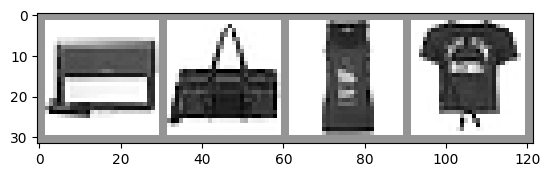

In [88]:
dataiter = iter(training_loader)
images, labels = next(dataiter)

img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)


In [90]:
dataiter = iter(training_loader)
images, labels = next(dataiter)

img_grid = torchvision.utils.make_grid(images)

from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs/fashion_mnist_experiment_1')

writer.add_image('Four Fashion-MNIST Images', img_grid)
writer.flush()

In [96]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    

net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [97]:
print(len(validation_loader))
for epoch in range(1):
    running_loss = 0.0

    for i, data in enumerate(training_loader, 0):
        # basic training loop
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if i % 1000 == 999:    
            print('Batch {}'.format(i + 1))
            running_vloss = 0.0
            
            net.train(False)
            for j, vdata in enumerate(validation_loader, 0):
                vinputs, vlabels = vdata
                voutputs = net(vinputs)
                vloss = criterion(voutputs, vlabels)
                running_vloss += vloss.item()
            net.train(True) 
            
            avg_loss = running_loss / 1000
            avg_vloss = running_vloss / len(validation_loader)
            
            writer.add_scalars('Training vs. Validation Loss',
                            { 'Training' : avg_loss, 'Validation' : avg_vloss },
                            epoch * len(training_loader) + i)

            running_loss = 0.0
print('Finished Training')

writer.flush()

2500
Batch 1000
Batch 2000
Batch 3000
Batch 4000
Batch 5000
Batch 6000
Batch 7000
Batch 8000
Batch 9000
Batch 10000
Batch 11000
Batch 12000
Batch 13000
Batch 14000
Batch 15000
Finished Training


In [99]:
dataiter = iter(training_loader)
images, labels = next(dataiter)

writer.add_graph(net, images)
writer.flush()

In [100]:
def select_n_random(data, labels, n=100):
    assert len(data) == len(labels)

    perm = torch.randperm(len(data))
    return data[perm][:n], labels[perm][:n]

images, labels = select_n_random(training_set.data, training_set.targets)

class_labels = [classes[label] for label in labels]

features = images.view(-1, 28 * 28)
writer.add_embedding(features,
                    metadata=class_labels,
                    label_img=images.unsqueeze(1))
writer.flush()
writer.close()

# Training Your Model in PyTorch


In [101]:
import torch
import torchvision
import torchvision.transforms as transforms

from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))])

training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

training_loader = torch.utils.data.DataLoader(training_set, batch_size=4, shuffle=True, num_workers=2)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=4, shuffle=False, num_workers=2)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot', 'Bag', 'Socks')

print('Training set has {} instances'.format(len(training_set)))
print('Validation set has {} instances'.format(len(validation_set)))

Training set has 60000 instances
Validation set has 10000 instances


T-shirt/top  Pullover  Shirt  Dress


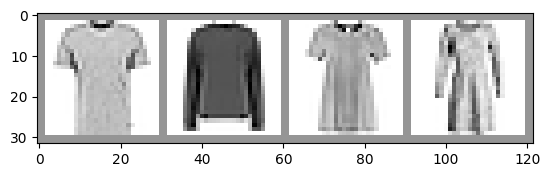

In [103]:
import matplotlib.pyplot as plt
import numpy as np

def matplotlib_imshow(img, one_channel=False):
    if one_channel:
        img = img.mean(dim=0)
    img = img / 2 + 0.5    
    npimg = img.numpy()
    if one_channel:
        plt.imshow(npimg, cmap="Greys")
    else:
        plt.imshow(np.transpose(npimg, (1, 2, 0)))

dataiter = iter(training_loader)
images, labels = next(dataiter)

img_grid = torchvision.utils.make_grid(images)
matplotlib_imshow(img_grid, one_channel=True)
print('  '.join(classes[labels[j]] for j in range(4)))

In [104]:
import torch.nn as nn
import torch.nn.functional as F

class GarmentClassifier(nn.Module):
    def __init__(self):
        super(GarmentClassifier, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 4 * 4)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x
    

model = GarmentClassifier()

In [105]:
loss_fn = torch.nn.CrossEntropyLoss()

dummy_outputs = torch.rand(4, 10)
dummy_labels = torch.tensor([1, 5, 3, 7])
    
print(dummy_outputs)
print(dummy_labels)

loss = loss_fn(dummy_outputs, dummy_labels)
print('Total loss for this batch: {}'.format(loss.item()))

tensor([[0.5945, 0.2301, 0.6952, 0.0586, 0.3711, 0.2577, 0.4611, 0.9584, 0.1598,
         0.7079],
        [0.4159, 0.4687, 0.0436, 0.9825, 0.9484, 0.7940, 0.2468, 0.4909, 0.0308,
         0.1286],
        [0.3885, 0.6405, 0.5729, 0.3868, 0.4744, 0.9290, 0.9095, 0.8107, 0.5477,
         0.6814],
        [0.9076, 0.7131, 0.1169, 0.5264, 0.9939, 0.2539, 0.0598, 0.0087, 0.9006,
         0.3348]])
tensor([1, 5, 3, 7])
Total loss for this batch: 2.497112274169922


In [106]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [108]:
def train_one_epoch(epoch_index, tb_writer):
    running_loss = 0.
    last_loss = 0.
    
    for i, data in enumerate(training_loader):
        inputs, labels = data
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        if i % 1000 == 999:
            last_loss = running_loss / 1000 # loss per batch
            print('  batch {} loss: {}'.format(i + 1, last_loss))
            tb_x = epoch_index * len(training_loader) + i + 1
            tb_writer.add_scalar('Loss/train', last_loss, tb_x)
            running_loss = 0.
            
    return last_loss

In [109]:
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
writer = SummaryWriter('runs/fashion_trainer_{}'.format(timestamp))
epoch_number = 0

In [ ]:
EPOCHS = 5

best_vloss = 1_000_000.

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))
    
    model.train(True)
    avg_loss = train_one_epoch(epoch_number, writer)
    
    model.train(False)
    
    running_vloss = 0.0
    for i, vdata in enumerate(validation_loader):
        vinputs, vlabels = vdata
        voutputs = model(vinputs)
        vloss = loss_fn(voutputs, vlabels)
        running_vloss += vloss
    
    avg_vloss = running_vloss / (i + 1)
    print('LOSS train {} valid {}'.format(avg_loss, avg_vloss))
    
    writer.add_scalars('Training vs. Validation Loss',
                    { 'Training' : avg_loss, 'Validation' : avg_vloss },
                    epoch_number + 1)
    writer.flush()
    
    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = 'model_{}_{}'.format(timestamp, epoch_number)
        torch.save(model.state_dict(), model_path)
    
    epoch_number += 1

EPOCH 6:
  batch 1000 loss: 0.2541134643713649
  batch 2000 loss: 0.2479827922521381
  batch 3000 loss: 0.279106739173639
  batch 4000 loss: 0.2584065965163645
  batch 5000 loss: 0.25390448562531676
  batch 6000 loss: 0.25113291533222126
  batch 7000 loss: 0.26730511114256295
  batch 8000 loss: 0.26249203137946825
  batch 9000 loss: 0.2626367427061341
  batch 10000 loss: 0.24938752229685268
  batch 11000 loss: 0.26810930226047774
  batch 12000 loss: 0.26189947396160823
  batch 13000 loss: 0.2493953981252671
  batch 14000 loss: 0.2650976966730204
  batch 15000 loss: 0.27331927013104906
LOSS train 0.27331927013104906 valid 0.31073057651519775
EPOCH 7:
  batch 1000 loss: 0.23810039448904355
  batch 2000 loss: 0.2432984052093012
  batch 3000 loss: 0.23628326210457773
  batch 4000 loss: 0.23368775323781665
  batch 5000 loss: 0.24670900286927475
  batch 6000 loss: 0.24913835365934575
  batch 7000 loss: 0.2505861671425354
  batch 8000 loss: 0.2744742030834834
  batch 9000 loss: 0.245471365521